   Year      Status  Life expectancy   Adult Mortality  infant deaths  \
0  2015  Developing              65.0            263.0             62   
1  2014  Developing              59.9            271.0             64   
2  2013  Developing              59.9            268.0             66   
3  2012  Developing              59.5            272.0             69   
4  2011  Developing              59.2            275.0             71   

   Alcohol  percentage expenditure  Hepatitis B  Measles    BMI   ...  Polio  \
0     0.01               71.279624         65.0      1154   19.1  ...    6.0   
1     0.01               73.523582         62.0       492   18.6  ...   58.0   
2     0.01               73.219243         64.0       430   18.1  ...   62.0   
3     0.01               78.184215         67.0      2787   17.6  ...   67.0   
4     0.01                7.097109         68.0      3013   17.2  ...   68.0   

   Total expenditure  Diphtheria    HIV/AIDS         GDP  Population  \
0       

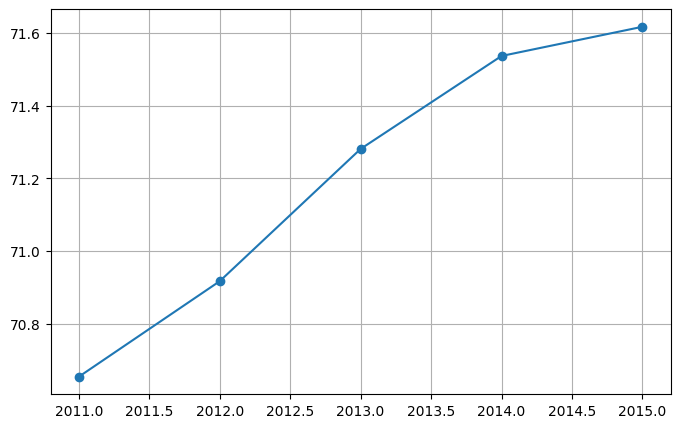

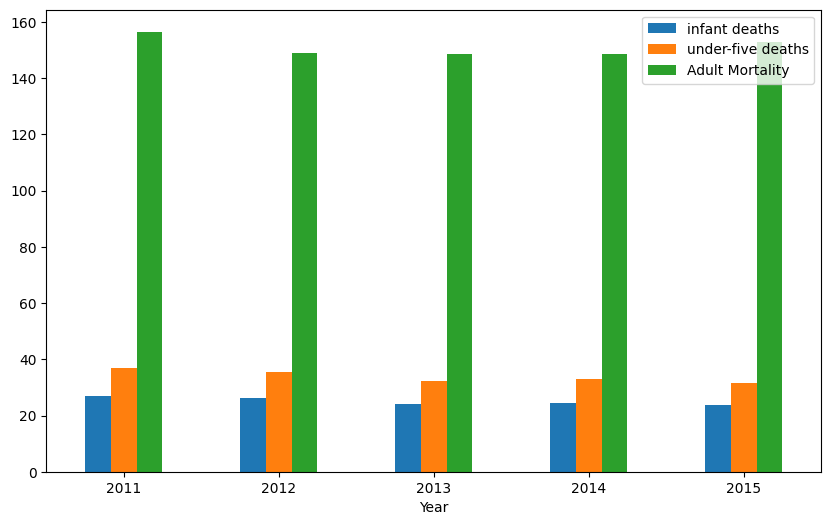

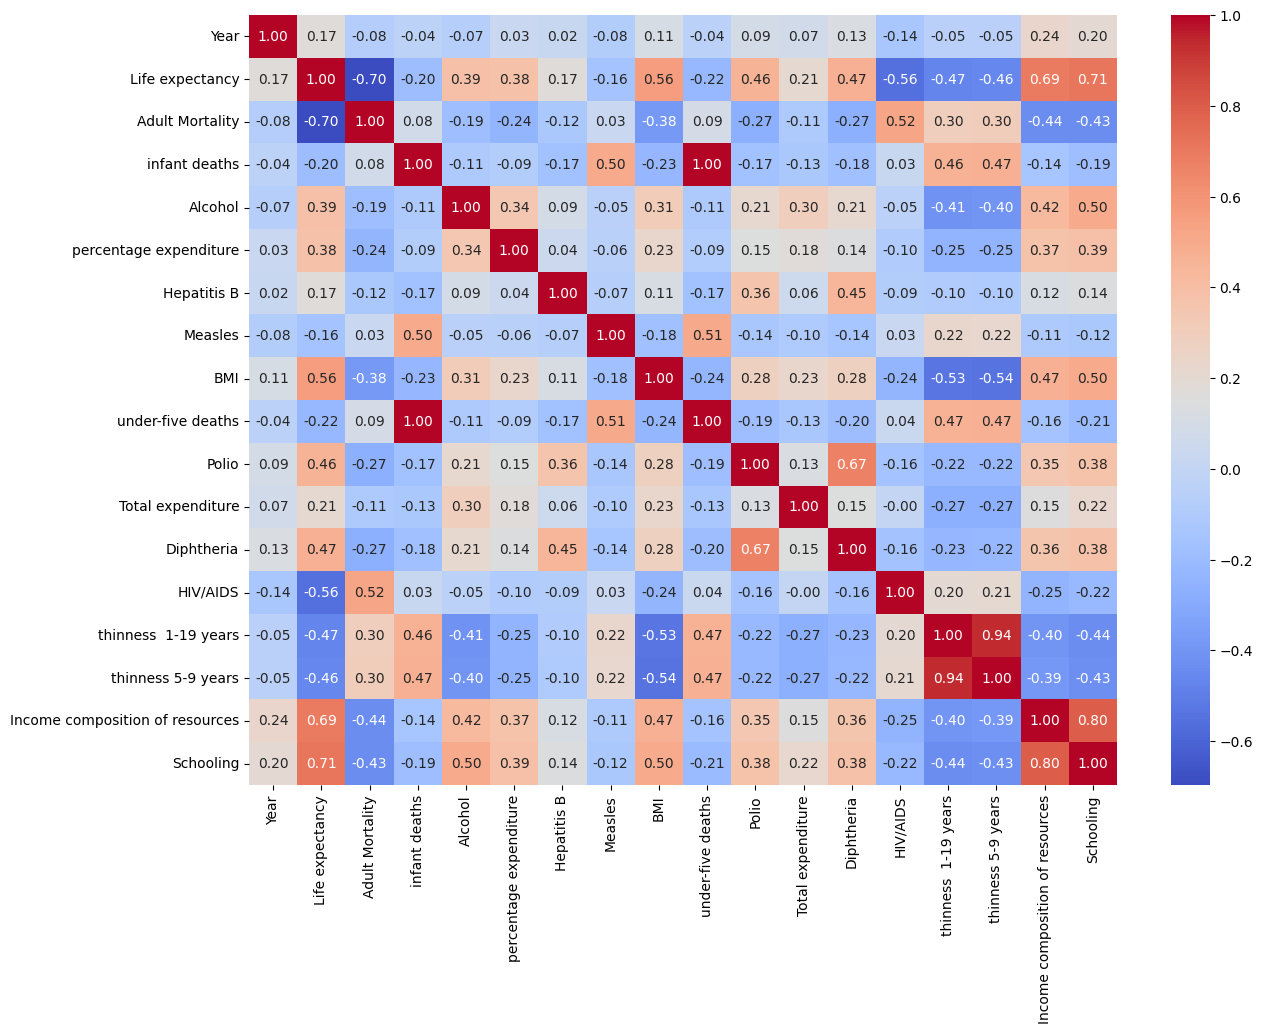

['Measles', 'Hepatitis B', 'Year']
Age            object
Income         object
Signup_Date    object
Color          object
Score           int64
dtype: object
Age                     int64
Income                float64
Signup_Date    datetime64[ns]
Color                category
Score                   int64
dtype: object
   Age    Income Signup_Date  Color  Score
0   25  1000.500  2023-01-15    Red     85
1   30  1500.000  2023-02-20   Blue     90
2   35  2000.750  2023-03-25  Green     78
3   40  1750.375  2023-04-30    Red     92
4   45  3000.250  2023-05-05   Blue     88


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from scipy.stats import skew

df = pd.read_csv('/Life_Expectancy_Data.csv')
print(df.head(), "\n")

df.columns = df.columns.str.strip()

df.info()
print(df.describe(), "\n")

print(df.isnull().sum(), "\n")

df = df.drop(columns=['Population', 'GDP'])

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum(), "\n")

print(df.shape)
print(df.duplicated().sum())

df = df.drop_duplicates()

print(df.shape, "\n")

print(num_cols.tolist(), "\n")

df_scaled = df.copy()

for col in num_cols:
    if col == 'Year':
        continue
    s = skew(df[col])
    if -0.5 <= s <= 0.5:
        scaler = StandardScaler()
    else:
        scaler = MinMaxScaler()
    df_scaled[col] = scaler.fit_transform(df[[col]])

print(cat_cols.tolist(), "\n")

le = LabelEncoder()
df_scaled['Status'] = le.fit_transform(df_scaled['Status'])

df_o = df[(df['Year'] >= 2011) & (df['Year'] <= 2015)]
yearly_avg = df_o.groupby('Year')['Life expectancy'].mean()

plt.figure(figsize=(8, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.grid(True)
plt.show()

grouped = df_o.groupby('Year')[['infant deaths', 'under-five deaths', 'Adult Mortality']].mean()
grouped.plot(kind='bar', figsize=(10, 6))
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

life_corr = corr['Life expectancy'].abs().sort_values()
least_corr_features = life_corr.head(3).index.tolist()

print(least_corr_features)

df_scaled = df_scaled.drop(columns=least_corr_features)

df_scaled.to_csv('cleaned1.csv', index=False)

data = {
    'Age': ['25', '30', '35', '40', '45'],
    'Income': ['$1000.5', '$1500.0', '$2000.75', '?', '$3000.25'],
    'Signup_Date': ['2023-01-15', '2023-02-20', '2023-03-25', '2023-04-30', '2023-05-05'],
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
    'Score': [85, 90, 78, 92, 88]
}

df2 = pd.DataFrame(data)

print(df2.dtypes)

df2['Age'] = df2['Age'].astype(int)

df2['Income'] = df2['Income'].str.replace('$', '', regex=False)
df2['Income'] = pd.to_numeric(df2['Income'], errors='coerce')
df2['Income'] = df2['Income'].fillna(df2['Income'].median())

df2['Signup_Date'] = pd.to_datetime(df2['Signup_Date'])
df2['Color'] = df2['Color'].astype('category')

print(df2.dtypes)
print(df2)